In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("/content/auto-mpg.csv")

In [3]:
if 'car name' in df.columns:
    carname = df['car name']
    df = df.drop(columns=['car name'])
else:
    print("'car name' column not found in DataFrame or already dropped.")

In [4]:
df.describe()

,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


In [5]:
# Replace '?' with NaN in 'horsepower' before determining column types
df['horsepower'] = df['horsepower'].replace('?', np.nan)

# Convert 'horsepower' to numeric, coercing errors to NaN
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

# Separate columns by type
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

In [6]:
# Calculate the median of the 'horsepower' column
horsepower_median = df['horsepower'].median()

# Fill NaN values in 'horsepower' with the calculated median
df['horsepower'].fillna(horsepower_median, inplace=True)

# Re-evaluate numerical and categorical columns after imputation
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print(f"'horsepower' NaNs filled with median: {horsepower_median}")
print(f"Updated numerical columns: {list(numerical_cols)}")
print(f"Updated categorical columns: {list(categorical_cols)}")

'horsepower' NaNs filled with median: 93.5
Updated numerical columns: ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year', 'origin']
Updated categorical columns: []


/tmp/ipykernel_925/3930486418.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['horsepower'].fillna(horsepower_median, inplace=True)


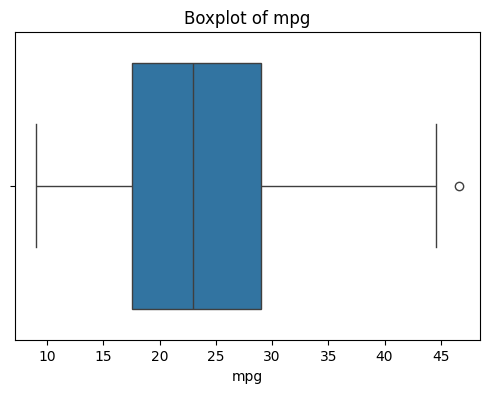

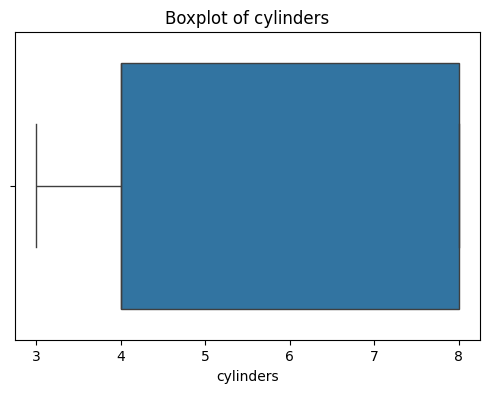

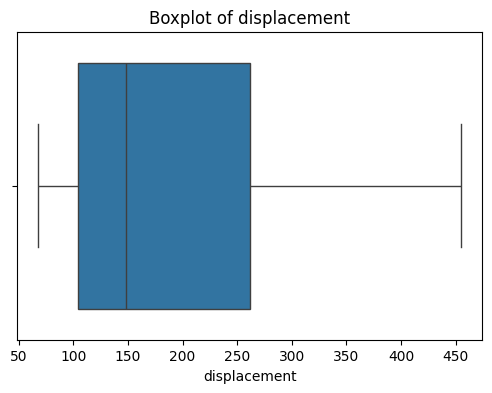

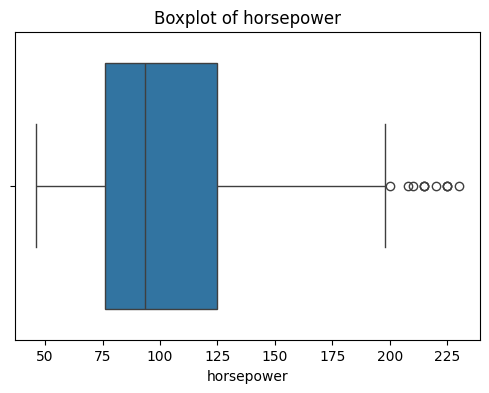

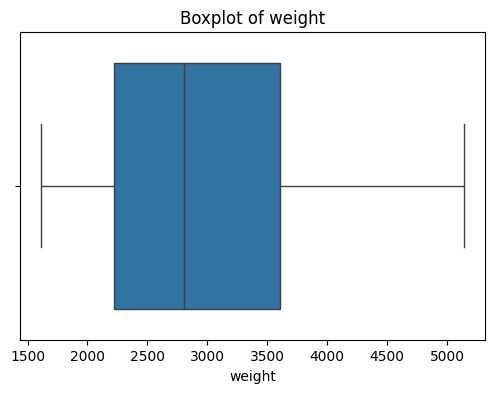

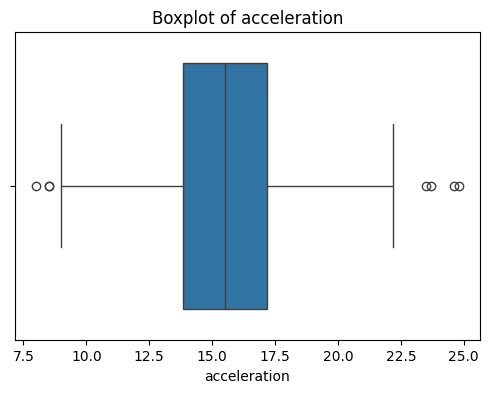

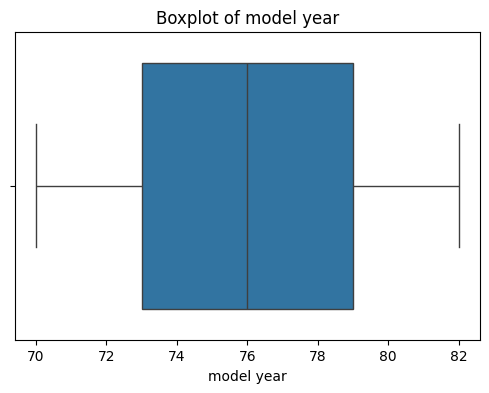

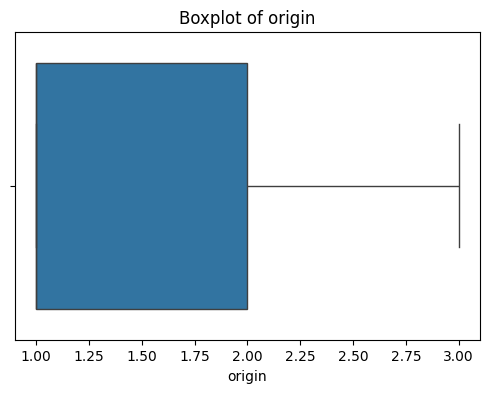

In [7]:
# --- Boxplot for all numerical columns ---
for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()


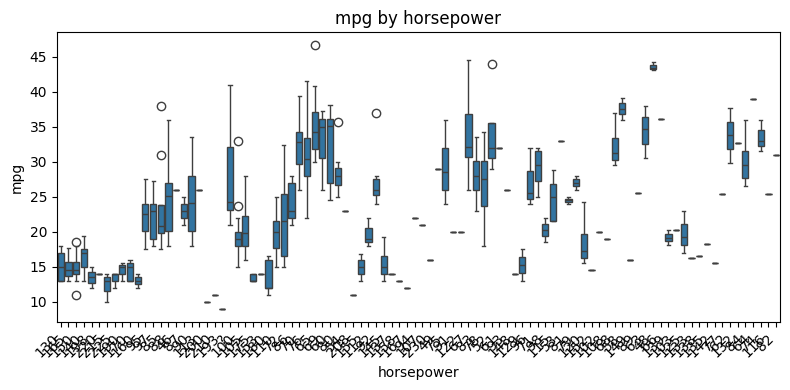

In [ ]:
# --- Boxplot: Customer Lifetime Value vs each categorical column ---
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=col, y='mpg', data=df)
    plt.title(f'mpg by {col}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

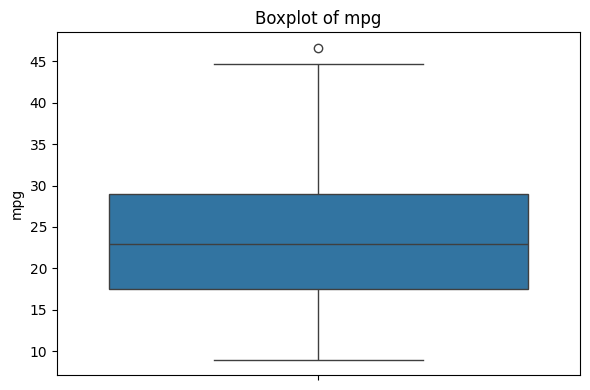

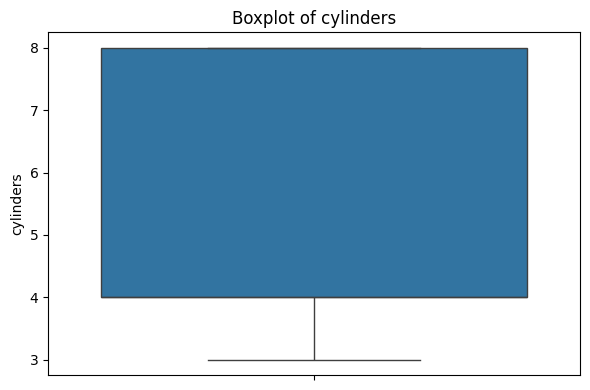

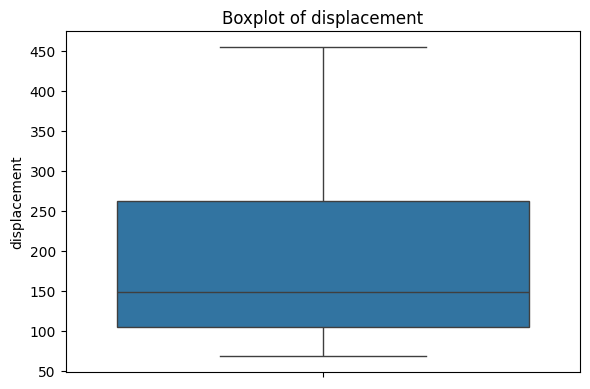

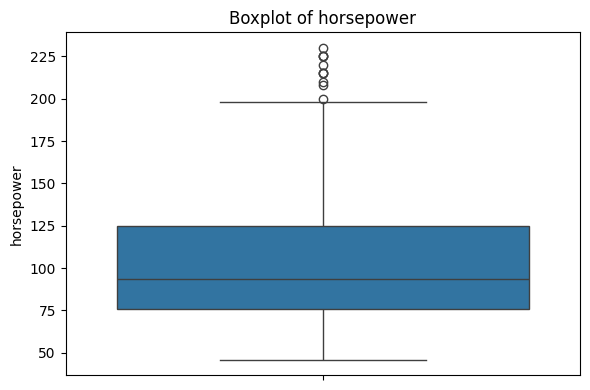

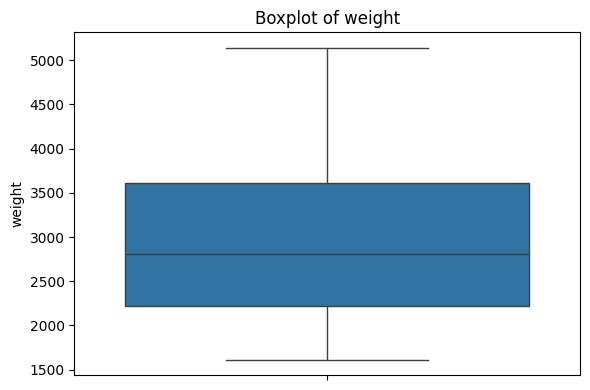

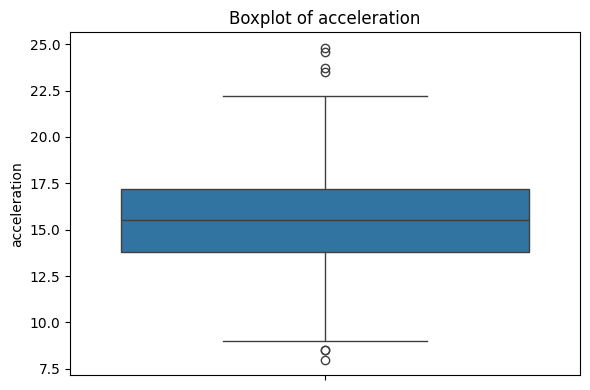

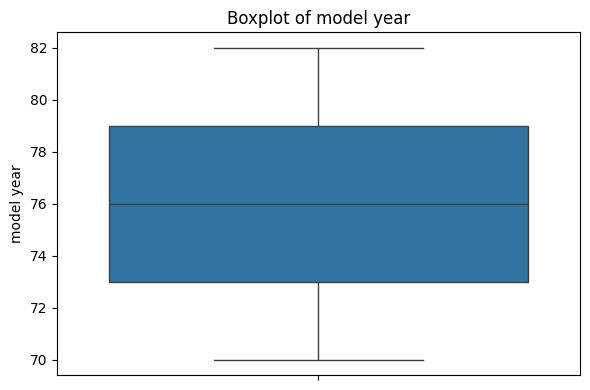

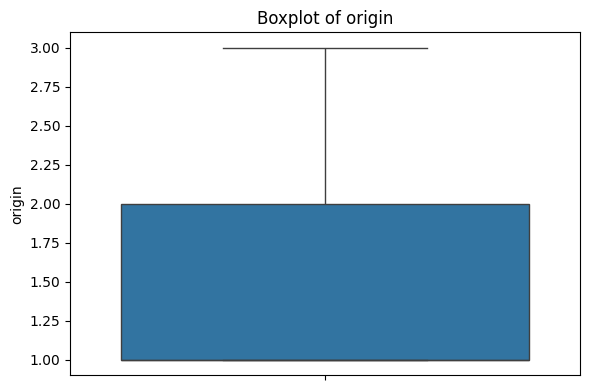

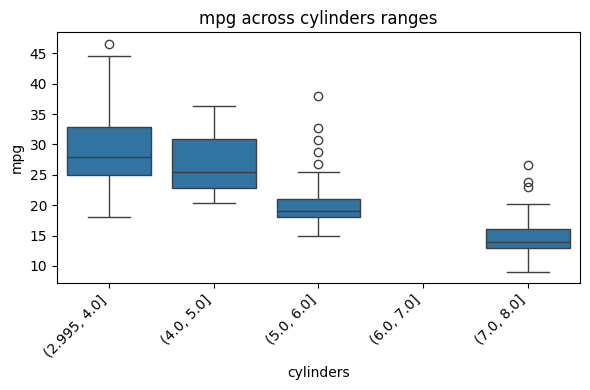

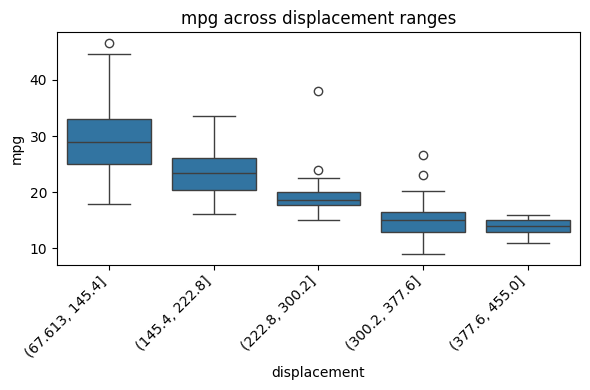

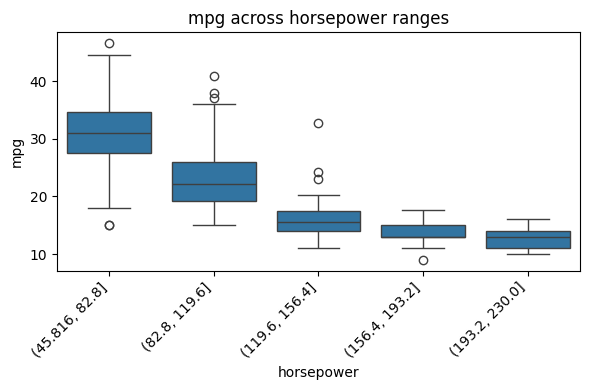

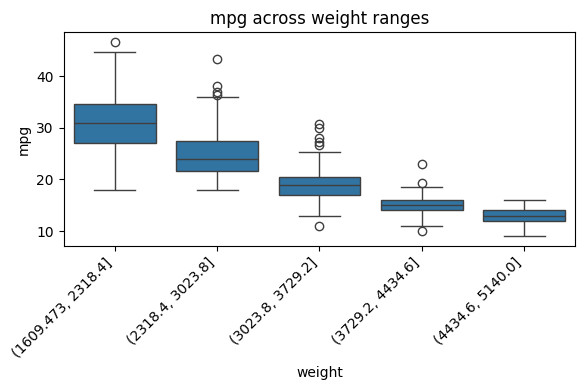

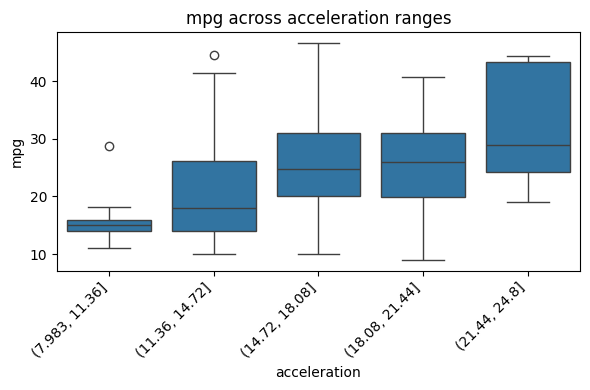

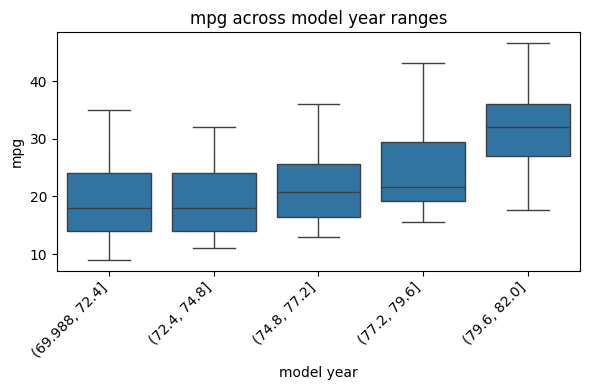

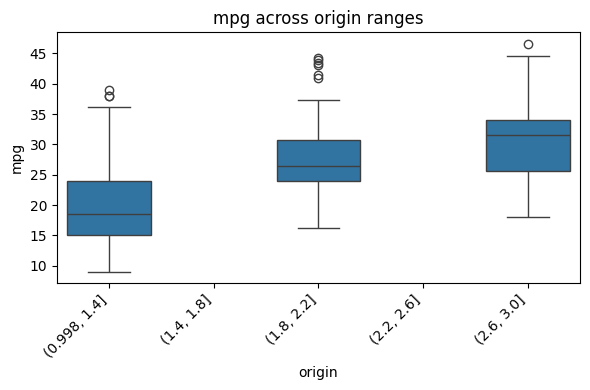

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Boxplot for all numerical columns (own distribution) ---
for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()

# --- Boxplot: Customer Lifetime Value vs each numerical column (binned) ---
for col in numerical_cols:
    if col != 'mpg':
        plt.figure(figsize=(6, 4))
        sns.boxplot(x=pd.cut(df[col], bins=5), y='mpg', data=df)
        plt.title(f'mpg across {col} ranges')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

# --- Countplot for all categorical columns (own distribution) ---
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=col, data=df, order=df[col].value_counts().index)
    plt.title(f'Countplot of {col}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [ ]:
print(df.select_dtypes(include=['object']).columns)

Index(['horsepower'], dtype='object')


In [ ]:
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.304020,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.222625,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,76.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,125.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


In [13]:
from sklearn.model_selection import train_test_split
Y=df["mpg"]
X=df.drop(["mpg"],axis=1)
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.3,random_state=42)

In [14]:
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score
model_lr=LinearRegression()
model_lr.fit(X_train,Y_train)
print("LR")
print(model_lr.score(X_train,Y_train))
print(model_lr.score(X_test,Y_test))




from sklearn.neighbors import KNeighborsRegressor

model_knn = KNeighborsRegressor()
model_knn.fit(X_train, Y_train)
print("KNR")
print(model_knn.score(X_train, Y_train))
print(model_knn.score(X_test, Y_test))

from sklearn.svm import SVR

model_svr = SVR()
model_svr.fit(X_train, Y_train)
print("SVR")
print(model_svr.score(X_train, Y_train))
print(model_svr.score(X_test, Y_test))


from sklearn.tree import DecisionTreeRegressor

model_dtr = DecisionTreeRegressor()
model_dtr.fit(X_train, Y_train)
print("DTR")
print(model_dtr.score(X_train, Y_train))
print(model_dtr.score(X_test, Y_test))

from sklearn.ensemble import BaggingRegressor

model_bag = BaggingRegressor()
model_bag.fit(X_train, Y_train)
print("BR")
print(model_bag.score(X_train, Y_train))
print(model_bag.score(X_test, Y_test))

from sklearn.ensemble import AdaBoostRegressor

model_ada = AdaBoostRegressor()
model_ada.fit(X_train, Y_train)
print("ABR")
print(model_ada.score(X_train, Y_train))
print(model_ada.score(X_test, Y_test))

from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor()
model_rf.fit(X_train, Y_train)
print("RFR")
print(model_rf.score(X_train, Y_train))
print(model_rf.score(X_test, Y_test))



LR
0.8108429889141731
0.8384465289489121
KNR
0.7928697120182524
0.7480381654402029
SVR
0.6619536447483323
0.7303021196194983
DTR
1.0
0.8057024743027781
BR
0.9744537529755961
0.8706093943383177
ABR
0.9103585890661029
0.8456095484760281
RFR
0.9804694777397828
0.8874822919785986


In [26]:
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score
model_lr=LinearRegression()
model_lr.fit(X_train,Y_train)
print("LR")
print(model_lr.score(X_train,Y_train))
print(model_lr.score(X_test,Y_test))




# from sklearn.neighbors import KNeighborsRegressor

# model_knn = KNeighborsRegressor(n_neighbors=2)
# model_knn.fit(X_train, Y_train)
# print("KNR")
# print(model_knn.score(X_train, Y_train))
# print(model_knn.score(X_test, Y_test))

# from sklearn.svm import SVR

# model_svr = SVR()
# model_svr.fit(X_train, Y_train)
# print("SVR")
# print(model_svr.score(X_train, Y_train))
# print(model_svr.score(X_test, Y_test))


from sklearn.tree import DecisionTreeRegressor

model_dtr = DecisionTreeRegressor(min_samples_leaf=12,min_samples_split=15,max_depth=6)
model_dtr.fit(X_train, Y_train)
print("DTR")
print(model_dtr.score(X_train, Y_train))
print(model_dtr.score(X_test, Y_test))

# from sklearn.ensemble import BaggingRegressor

# model_bag = BaggingRegressor()
# model_bag.fit(X_train, Y_train)
# print("BR")
# print(model_bag.score(X_train, Y_train))
# print(model_bag.score(X_test, Y_test))

# from sklearn.ensemble import AdaBoostRegressor
base = DecisionTreeRegressor(max_depth=2)
model_ada = AdaBoostRegressor(estimator=base, n_estimators=50, learning_rate=0.1, random_state=42)
model_ada.fit(X_train, Y_train)
print("ABR")
print(model_ada.score(X_train, Y_train))
print(model_ada.score(X_test, Y_test))

# from sklearn.ensemble import RandomForestRegressor

# model_rf = RandomForestRegressor(min_samples_leaf=12,min_samples_split=15,max_depth=6)
# model_rf.fit(X_train, Y_train)
# print("RFR")
# print(model_rf.score(X_train, Y_train))
# print(model_rf.score(X_test, Y_test))

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
model_poly_ridge  = Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    #("lr", LinearRegression()),
    ("scale", StandardScaler()),
    ("ridge", RidgeCV(alphas=[0.01, 0.1, 1, 10, 100], cv=5))
])
model_poly_ridge.fit(X_train, Y_train)
print("Poly + Ridge")
print(model_poly_ridge.score(X_train, Y_train))
print(model_poly_ridge.score(X_test, Y_test))

# model_poly.fit(X_train, Y_train)
# print("Poly")
# print(model_poly.score(X_train, Y_train))
# print(model_poly.score(X_test, Y_test))

import xgboost as xgb

model_xgb = xgb.XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
model_xgb.fit(X_train, Y_train)
print("XGB")
print(model_xgb.score(X_train, Y_train))
print(model_xgb.score(X_test, Y_test))



LR
0.8108429889141731
0.8384465289489121
DTR
0.882772732527736
0.8387078363912075
ABR
0.8465806078641437
0.8359203018229098
Poly + Ridge
0.8900066987395627
0.8839586823638791
XGB
0.9671201514990388
0.8766523850448963


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Define parameter grid to combat overfitting
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [8, 12, 16],  # Prevents infinite tree depth
    'min_samples_leaf': [2, 4, 8],  # Prevents fitting single noisy points
    'min_samples_split': [5, 10],
}

rf = RandomForestRegressor(random_state=42)

# Use 5-fold cross-validation to find best hyperparameters
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
)

grid_search.fit(X_train, Y_train)

# Evaluate tuned model
best_rf = grid_search.best_estimator_
print(f'Best Parameters: {grid_search.best_params_}')
print(f'Tuned Train R2: {best_rf.score(X_train, Y_train):.4f}')
print(f'Tuned Test R2: {best_rf.score(X_test, Y_test):.4f}')

Best Parameters: {'max_depth': 8, 'min_samples_leaf': 4, 'min_samples_split': 5, 'n_estimators': 200}
Tuned Train R2: 0.9408
Tuned Test R2: 0.8333
